# Data distributions

> **Chapter resources**
>
> <a href="../files/slides/05_distributions.pdf"
> class="btn btn-sm btn-primary">Slides (PDF)</a> <a
> href="https://colab.research.google.com/github/antoninofurnari/fad-2627/blob/main/notes/05_distributions.ipynb"
> class="btn btn-sm btn-outline-primary">Open in Colab</a>
> <a href="../files/chapters/05_distributions.pdf"
> class="btn btn-sm btn-outline-primary btn-chapter-pdf">Download PDF</a>
> <a href="../quiz.html?bank=05"
> class="btn btn-sm btn-outline-primary">Practice quiz</a>

We have seen how it is possible to assign a probability value to a given
outcome of a random variable.

In practice, it is often useful to assign probability values to **all
the values** that the random variable can assume.

To do so, we can define a **function**, which we will call **probability
distribution** which assigns a probability value to each of the possible
values of a random variable.

In the case of discrete variables, we will talk about “**probability
mass functions**”, whereas in the case of continuous variables, we will
refer to “**probability density functions**”.

A probability distribution characterizes the random variable and defines
which outcomes it is more likely to observe.

Once we find that a given random variable $X$ is characterized by a
probability distribution $P(X)$, we can say that **“X follows P”** and
write:

$$X \sim P$$

## Discrete Variables

We will start by focusing on discrete variables.

### Probability Mass Functions (PMF)

If $X$ is discrete, $P(X)$ is called a “probability mass function”
(PMF).

$P$ can be seen as a function mapping the values of $X$ to real numbers
indicating whether a given value is more or less likely.

A PMF on a random variable $X$ is a function:

$$P:\Omega \rightarrow \lbrack 0,1\rbrack$$

which satisfies the following property:

$$\sum_{\mathbf{x}\mathbf{\in}\mathbf{\Omega}}^{}{\mathbf{P}\mathbf{(}\mathbf{x}\mathbf{)}}\mathbf{=}\mathbf{1}$$

where $\Omega$ is the sample space $X$,

This condition implies that the probability distribution is normalized
(and probability axioms are satisfied).

#### Example: Probability Mass Function for a Fair Coin

Let $X$ be the random variable indicating the outcome of a coin toss.

-   The space of all possible outcomes (the domain of $P(X)$) is
    $\{ head,\ tail\}$.

-   The probabilities $P(head)$ and $P(tail)$ must be l**arger than or
    equal to zero and smaller than or equal to 1**.

-   Also, $P(head) + P(tail) = 1\ $. This is obvious, as one of the two
    outcomes will always happen. Indeed, if we had $P(tail) = 0.3$, this
    would mean that, $30$ times out of $100$ times we toss a coin, the
    outcome will be tail. What will happen in all other cases? The
    outcome will be head, hence, $P(head)=0.7$, so
    $P(head) + P(tail) = 1$.

-   In the case of a fair coin, we can characterize $P(X)$ as a
    **“discrete uniform distribution”**, i.e., a distribution which maps
    any value $x \in X$ to a constant, such that the properties of the
    probability mass functions are satisfied.

-   If we have $N$ possible outcomes, the discrete uniform probability
    will be $P(X = x) = \frac{1}{N}$ , which means that all outcomes
    have the same probability.

-   This definition satisfies the constraints. Indeed:

    -   $\frac{1}{N} \geq 0,\ \forall N$
    -   $\sum_{i}^{}{P\left( X = x_{i} \right)} = 1$

A probability mass function can be visualized as a 2D diagram where the
values of the function ($P(x)$) is plotted against the values of the
independent variable $x$. This is the diagram associated to the PMF of
the previous example, where $P(head) = P(tail) = 0.5$.

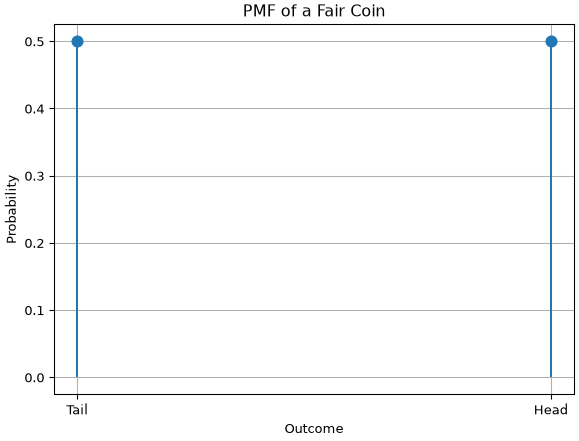

#### Example: Probability Mass Function for a Biased Coin

Now suppose we tossed our coin for 10000 times and discovered that 6000
times the outcome was “head”, whereas 4000 times it was “tail”. We
deduce the coin is not fair.

Using a **frequentist** approach, we can manually assign values to our
PMF using the general formula:

$$P(x) = \frac{\# trials\ in\ which\ X = x}{\#\ trials}$$

That is, in our case:

$$P(head) = \frac{6000}{10000} = 0.6;P(tail) = \frac{4000}{10000} = 0.4$$

We shall note that the probability we just defined satisfies all
properties of probabilities, i.e.:

-   $0 \leq P(x) \leq 1\ \forall x$

-   $\sum_{x}^{}{P(x) = 1}.$

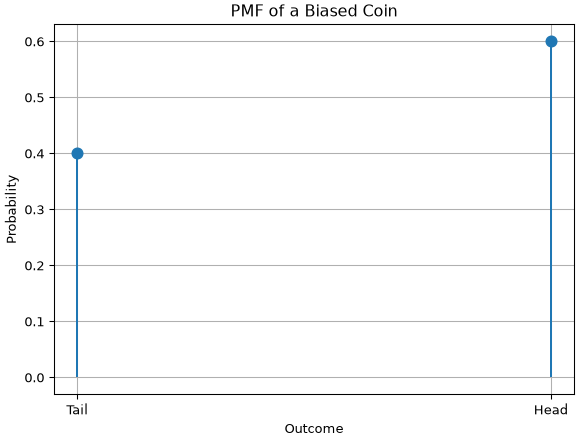

#### Computing Probability Mass Functions from Data

In practice, Probability Mass Functions are computed exactly as relative
frequencies. Let’s see a quick example:

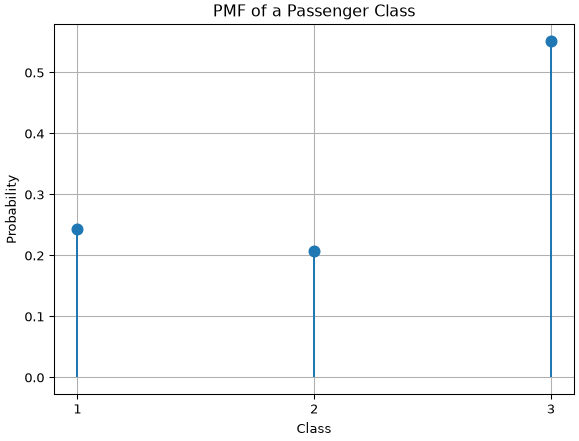

In [4]:
import pandas as pd
titanic = pd.read_csv(DATA + "titanic.csv",
                     index_col='PassengerId')
pclass = titanic['Pclass'].value_counts(normalize=True).sort_index()

plt.vlines(pclass.index.values, ymin=0, ymax=pclass.values,  linestyles='solid')
plt.plot(pclass.index.values, pclass.values, 'o', markersize=8)
plt.xlabel('Class')
plt.ylabel('Probability')
plt.title('PMF of a Passenger Class')
plt.xticks(pclass.index.values)
plt.grid(True)

# Show the plot
plt.show()

#### Exercise: Probability Mass Function

Let $X$ be a random variable representing the outcome of rolling a fair
dice with $6$ faces:

-   What is the space of possible values of $X$?

-   What is its cardinality?

-   What is the associated probability mass function $P(X)$?

-   Suppose the dice is not fair and $P(X = 1) = 0.2$, whereas all other
    outcomes are equally probable. What is the probability mass function
    of $P(X)$?

-   Draw the PMF obtained for the dice.

### Cumulative Distribution Functions of Discrete Variables

If the discrete variable $X$ can be ordered (i.e., it is at least
ordinal), we can define the **Cumulative Distribution Function (CDF)**
as:

$$F(x) = P(X \leq x) = \sum_{y \leq x} P(y)$$

The CDF records the cumulative probability of all values less than or
equal to a given value. For example, if $H$ measures the height of
people in centimeters, $F(180)$ indicates the **probability of selecting
a person with height at most 180 cm**.

#### Example – PMF and CDF of a fair die

For a fair die, the PMF is:

$$
f(x) = \begin{cases}
\frac{1}{6} & \text{if } x \in \{1, 2, 3, 4, 5, 6\} \\
0 & \text{otherwise}
\end{cases}
$$

The CDF is:

$$
F(x) = \begin{cases}
0 & \text{if } x < 1 \\
\frac{1}{6} & \text{if } 1 \leq x < 2 \\
\frac{2}{6} & \text{if } 2 \leq x < 3 \\
\frac{3}{6} & \text{if } 3 \leq x < 4 \\
\frac{4}{6} & \text{if } 4 \leq x < 5 \\
\frac{5}{6} & \text{if } 5 \leq x < 6 \\
1 & \text{if } x \geq 6
\end{cases}
$$

The diagram below shows an example:

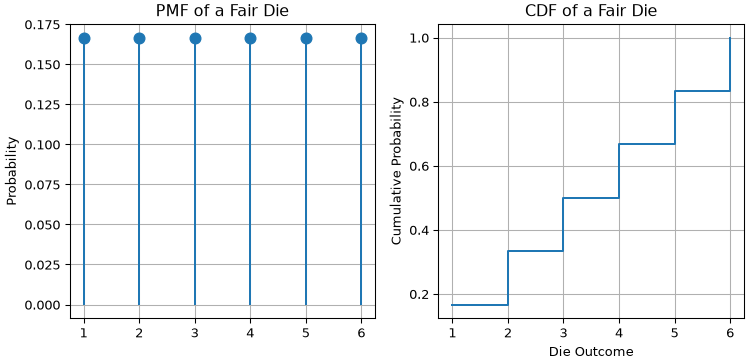

#### Computing CDFs for Discrete Variables from Data

Empirical Cumulative Distribution Functions (ECDFs), introduced in the
lecture on data description, allow us to estimate the CDF directly from
observed data. For a discrete variable, the ECDF at a value $x$ is
simply the proportion of data points less than or equal to $x$.

Here is a quick example:

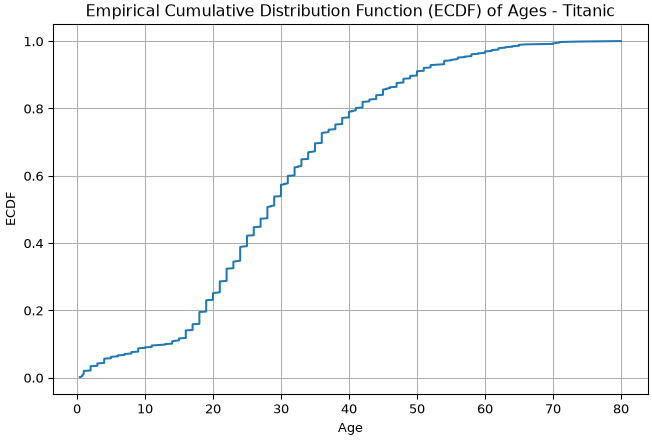

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic = pd.read_csv(DATA + "titanic.csv", index_col='PassengerId')

# Extract the age column, removing missing values
ages = titanic['Age'].dropna()

# Sort the ages
ages_sorted = np.sort(ages)

# Compute the ECDF
ecdf = np.arange(1, len(ages_sorted)+1) / len(ages_sorted)

# Plot the ECDF
plt.figure(figsize=(8, 5))
plt.plot(ages_sorted, ecdf)
plt.xlabel('Age')
plt.ylabel('ECDF')
plt.title('Empirical Cumulative Distribution Function (ECDF) of Ages - Titanic')
plt.grid(True)
plt.show()

## Continuous Variables

We will now focus on the case in which $X$ is a continuous variable. In
this case, we cannot use the same definitions as for discrete variables
and we have to resort to new definition.

### Probability Density Functions (PDF)

In order to define a probability distribution over a continuous
variable, we first have to introduce the concept of “probability density
function”.

A probability density function over a variable $X$ is defined as
follows:

$$ f:\Omega \rightarrow [0,1] $$

and must satisfy the following property:

$$\int f(x)\,dx = 1$$

This condition is equivalent to $\sum P(x) = 1$ in the case of a
discrete variable. The sum becomes an integral for continuous variables.

We can then define the concept of probability based on the density as
follows:

$$ P(a \leq x \leq b) = \int_{a}^b f(x)\,dx $$

**Intuitively, the density function $f(x)$ describes how likely it is to
observe values near $x$. The higher the density at a point, the more
likely it is to find the variable in a small interval around that point.
In other words, the density can be seen as a “concentration” of
probability: regions where $f(x)$ is high correspond to intervals where
the variable is more frequently observed. To obtain an actual
probability, we must integrate the density over an interval.**

> For a continuous random variable, the probability of observing exactly
> $x$ is zero: $P(X = x) = 0$. However, the density function $f(x)$ at
> $x$ is generally not zero; it represents the probability per unit
> interval around $x$. Probability is obtained by integrating $f(x)$
> over an interval, not at a single point.

#### Example: Uniform PDF

Let us consider a random number generator which outputs numbers
comprised between $a$ and $b$.

Let $X$ be a random variable assuming the values generated by the random
number generator.

The PDF of $X$ will be a uniform distribution such that:

-   $P(x) = 0\ \forall x < a\ \ or\ x > b$;

-   $P(x) = \frac{1}{b - a}\ \forall a \leq x \leq b$;

We can see that this PDF satisfies all constraints:

-   $P(x) \geq 0\ \forall x.$

-   $\int P(x)dx = 1$ (prove that this is true as an exercise).

The diagram below shows an illustration of a uniform PDF with bounds a
and b:

$$U(a,b)$$

Of course, continuous distributions can be (and generally are) much more
complicated than that.

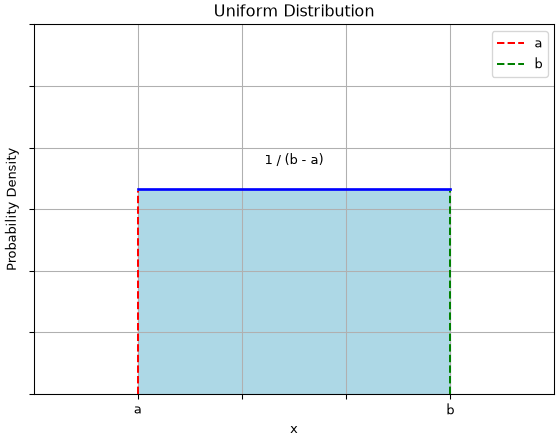

#### Approximating a PDF with Density Histograms and Density Estimates

When working with real data, we can try to approximate the PDF of a
continuous variable with histograms.

Let the height and width of bin $b_j$ be $h_j$ and $w_j$ respectively.
In a **normalized histogram**, we define the height of bin $b_j$ as
follows:

$$h_j=\frac{c_j}{n}$$

where $c_j$ is the number of observations that fall in bin $b_j$.

Note that, while **normalized histograms** are such that each bar height
is comprised between $0$ and $1$, they do not satisfy the properties of
PDFs.

Let the area of bin $b_j$ be:

$$A_j = w_j \cdot h_j$$

The integral over histogram $H$ (i.e., the area under the histogram)
will be:

$$\int_{-\infty}^{\infty} H(x) dx = \sum_j A_j = \sum_j w_j \frac{c_j}{n} = \frac{1}{n}\sum_j w_j \cdot c_j = \sum w_j \neq 1$$

To ensure that this property is satisfied, we define a new kind of
histogram, the **density histogram**, where bin heights are defined as:

$$h_j = \frac{c_j}{w_j \cdot n}$$

In this case:

$$\sum_j A_j = \sum_j w_j \frac{c_j}{w_j \cdot n} = \frac{1}{n}\sum_j \frac{w_j}{w_j} \cdot c_j = 1$$

To create a density histogram in Python, simply pass `density=True` to
the `hist` function in matplotlib or pandas.

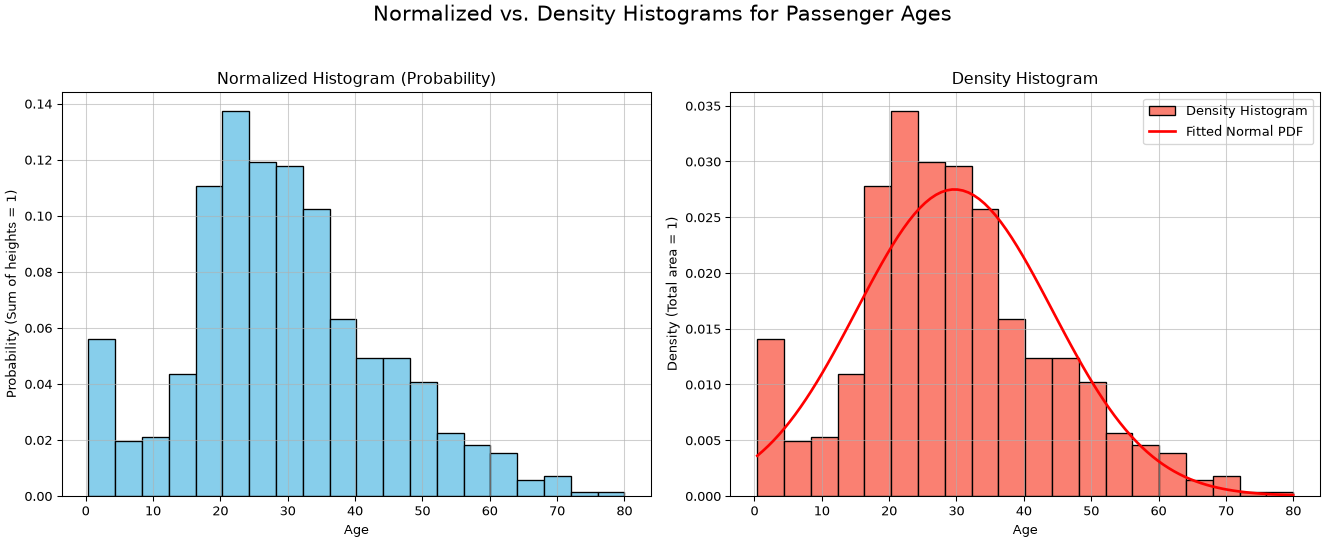

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load the Titanic dataset and extract the 'Age' column, dropping missing values
titanic = pd.read_csv(DATA + "titanic.csv")
ages = titanic['Age'].dropna()

# Create a figure with two subplots for side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Normalized Histogram (Probability) ---
# The sum of bar heights will equal 1
weights = np.ones_like(ages) / len(ages)
ax1.hist(ages, bins=20, weights=weights, color='skyblue', edgecolor='black')
ax1.set_title('Normalized Histogram (Probability)')
ax1.set_xlabel('Age')
ax1.set_ylabel('Probability (Sum of heights = 1)')
ax1.grid(True, alpha=0.6)

# --- Plot 2: Density Histogram ---
# The total area of the bars will equal 1
ax2.hist(ages, bins=20, density=True, color='salmon', edgecolor='black', label='Density Histogram')

# Fit a normal distribution and overlay its PDF
mu_hat, sigma_hat = norm.fit(ages)
x = np.linspace(ages.min(), ages.max(), 100)
pdf_fitted = norm.pdf(x, loc=mu_hat, scale=sigma_hat)
ax2.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted Normal PDF')

ax2.set_title('Density Histogram')
ax2.set_xlabel('Age')
ax2.set_ylabel('Density (Total area = 1)')
ax2.grid(True, alpha=0.6)
ax2.legend()

# Add an overall title and show the plot
plt.suptitle('Normalized vs. Density Histograms for Passenger Ages', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for suptitle
plt.show()

The figure above contrasts two important ways to normalize a histogram
using Titanic passenger ages, each with a distinct but related
interpretation:

-   **Normalized Histogram (Left)**:  
    The y-axis represents **probability**. Each bar’s height shows the
    proportion of passengers in that age bin, so the **sum of all bar
    heights equals 1**. This treats the binned data like a discrete
    probability distribution and allows direct reading of probabilities
    (e.g., the chance of being 20–24 years old is roughly 0.12 or 12%).

-   **Density Histogram (Right)**:  
    The y-axis represents **density**—probability per unit on the x-axis
    (e.g., per year of age). Here, it’s the **area** of each bar (height
    × width) that reflects probability. The **total area of all bars
    equals 1**, mirroring the behavior of a continuous Probability
    Density Function (PDF).

**Key takeaway**:  
The density histogram is the correct empirical approximation of a
continuous PDF. That’s why the smooth red PDF curve aligns with the
right plot’s y-axis but would be mis-scaled on the left. While both
histograms are normalized, only the density version properly reflects
continuous probability.

### Cumulative Distribution Functions (CDF)

Just like in the case of discrete variables, we can define Cumulative
Distribution Functions (CDFs) for continuous random variables using
their density functions. The CDF of a random variable is generally
defined as:

$$ F(x) = \int_{-\infty}^x f(x)\,dx $$

### Example

The CDF of the uniform distribution will be given by:

-   $F(x) = 0$ for $x < a$
-   $F(x) = \frac{x - a}{b - a}$ for $a \leq x \leq b$
-   $F(x) = 1$ for $x > b$

The plot below shows a diagram:

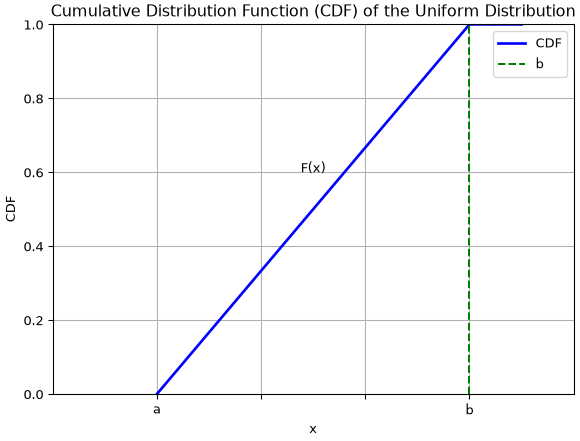

## Common Probability Distributions

There are several common probability distributions which can be used to
describe random events. **These distributions have an analytical
formulation which depends generally on one or more parameters.**

When we have **enough evidence that a given random variable is well
described by one of these distributions**, we can simply “fit” the
distribution to the data (i.e., choose the correct parameters for the
distribution) and use the analytical formulation to deal with the random
variable.

It is hence useful to know the **most common probability distributions**
so that we can recognize the cases in which they can be used.

### Discrete Uniform Distribution

The discrete uniform distribution is controlled by a parameter
$k \in \mathbb{N}$ and assumes that all outcomes have the same
probability of occurring:

$$P(X=a_i) = \frac{1}{k}$$

Where $\Omega = \{a_1,\ldots,a_k\}$.

#### Example

The outcomes of rolling a fair die follow a uniform distribution with
$k=6$, as shown in the diagram below:

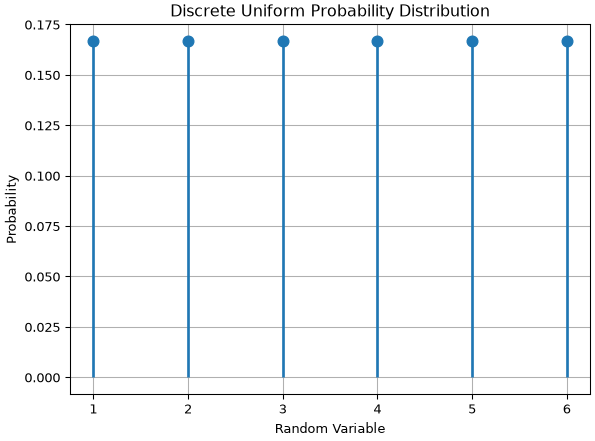

### Bernoulli Distribution

The Bernoulli distribution is a distribution over a single binary random
variable, i.e., the variable $X$ can take only two values:
$\left\{ 0,1 \right\}$.

The distribution is controlled by a single parameter
$\phi \in \lbrack 0,1\rbrack$, which gives the probability of the
variable to be equal to 1.

The analytical formulation of the Bernoulli distribution is very simple:

-   $P(X = 1) = \phi$;

-   $P(X = 0) = 1 - \phi$

#### Example

A skewed coin lands on “head” $60\%$ of the times. If we define $X = 1$
when the outcome is head and $X = 0$ when the outcome is tail, then the
variable follows a Bernoulli distribution with $\phi = 0.6$.

The diagram below gives an example:

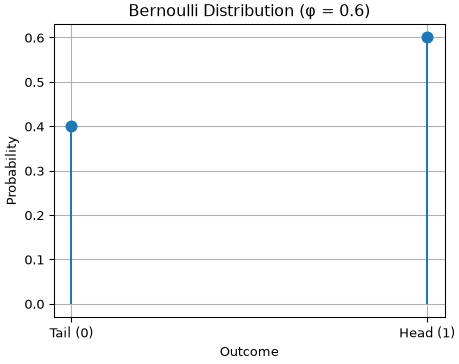

### Binomial Distribution

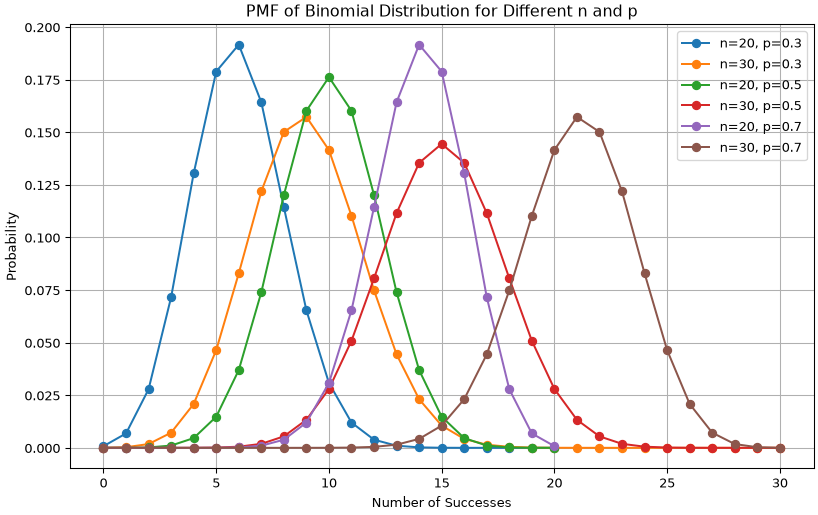

The binomial distribution is a discrete probability distribution (PMF)
over natural numbers with parameters $\mathbf{n}$ **and** $\mathbf{p}$

It models **the probability of obtaining** $\mathbf{k}$ **successes in a
sequence of** $\mathbf{n}$ **independent experiments which follow a
Bernoulli distribution with parameter**
$\mathbf{p}\mathbf{\ (}\mathbf{\phi}\mathbf{=}\mathbf{p}\mathbf{)}$**;**

The probability mass function of the distribution is given by:

$$P(k) = \binom{n}{k}p^{k}(1 - p)^{n - k}$$

Where:

-   $k$ is the number of successes

-   $n$ is the number of independent trials

-   $p$ is the probability of a success in a single trial

#### Example

What is the probability of tossing a coin three times and obtaining
three heads? We have:

-   $k = 3$: number of successes (three times head)

-   $n = 3$: number of trials

-   $p = 0.5$: the probability of getting a head when tossing a coin

The required probability will be given by:

$$P(3) = \binom{3}{3}{0.5}^{3}(1 - 0.5)^{3 - 3} = {0.5}^{3} = 0.125$$

**Exercise**

What is the probability of tossing an unfair coin
($P\left( 'head^{'} \right) = 0.6$) 7 times and obtaining $2$ tails?

### Categorical Distribution

The **multinoulli** or **categorical** distribution is a distribution of
a *single discrete variable with* $k$ *different states*, where $k$ is
finite.

-   The distribution is parametrized by a vector
    $\mathbf{p} \in \lbrack 0,1\rbrack^k$, where $p_{i}$ gives the
    probability of the $i^{th}$ state.

-   $\mathbf{p}$ must be such that $\sum_{i = 1}^kp_{i} = 1$ to obtain a
    valid probability distribution.

-   The analytical form of the distribution is given by:
    $p(x = i) = p_{i}$;

This distribution is the **generalization of the Bernoulli distribution
to the case of multiple states**.

**Example: Rolling a Biased Die**

Consider a single roll of a biased six-sided die. The outcomes are
discrete and finite: $X \in \{1, 2, 3, 4, 5, 6\}$.

If the die is biased such that the probabilities are:

-   $P(X=1) = 0.10$
-   $P(X=2) = 0.15$
-   $P(X=3) = 0.20$
-   $P(X=4) = 0.20$
-   $P(X=5) = 0.10$
-   $P(X=6) = 0.25$

Then the outcome follows a **Categorical distribution** with $k = 6$ and
the specified probabilities
$\{p_1, p_2, \dots, p_6\} = \{0.1,0.15,0.2,0.2,0.1,0.25\}$.

The figure below shows an example:

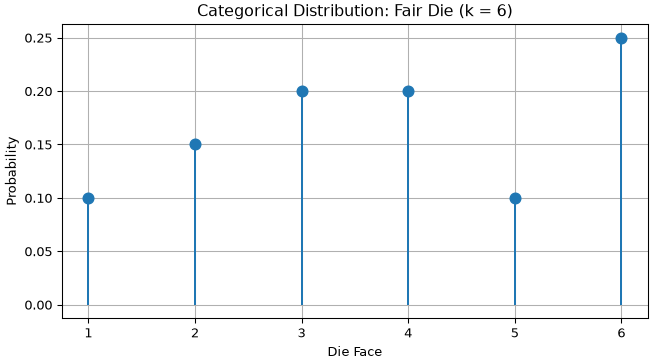

### Multinomial Distribution

The multinomial distribution **generalizes the binomial distribution to
the case in which the experiments are not binary**, but they can have
multiple outcomes (e.g., *a dice vs a coin*).

In particular, the multinomial distribution models the probability of
obtaining exactly $(n_{1},\ldots,n_{k})$ occurrences (with
$n = \sum_{i}^{}n_{i}$) for each of the $k$ possible outcomes in a
sequence of $n$ independent experiments which follow a Categorial
distribution with probabilities $p_{1},\ldots,p_{k}$.

The parameters of the distribution are:

-   $n$: the number of trials

-   $k$: the number of possible outcomes

-   $p_{1},\ldots,p_{k}$ the probabilities of obtaining a given class in
    each trial (with $\sum_{i = 1}^{k}p_{i} = 1$)

The PMF of the distribution is:

$$P\left( n_{1},\ldots,n_{k} \right) = \frac{n!}{n_{1}!\ldots n_{k}!}p_{1}^{n_{1}} \cdot \ldots \cdot p_{k}^{n_{k}}$$

#### Example

Given a fair die with 6 possible outcomes, what is the probability of
getting 3 times 1, 2 times 2, 4 time 3, 5 times 4, 0 times 5, and 1 time
6, rolling the dice for 15 times?

We have:

-   $n = 15$

-   $k = 6$

-   $p_{1} = p_{2} = \ldots p_{6} = \frac{1}{6}$

The required probability is given by:

$$P(3,2,4,5,0,1) = \frac{15!}{3!2!4!5!0!1!} \cdot \frac{1}{6^{3}} \cdot \frac{1}{6^{2}} \cdot \frac{1}{6^{4}} \cdot \frac{1}{6^{5}} \cdot \frac{1}{6^{0}} \cdot \frac{1}{6^{1}} = 8.04 \cdot 10^{- 5}$$

The bar chart below illustrate the example, showing the observed counts
and the estimated probability.

This low probability reflects the combinatorial nature of the
multinomial distribution, which accounts for both the number of ways the
outcomes can be arranged and the likelihood of each individual outcome.

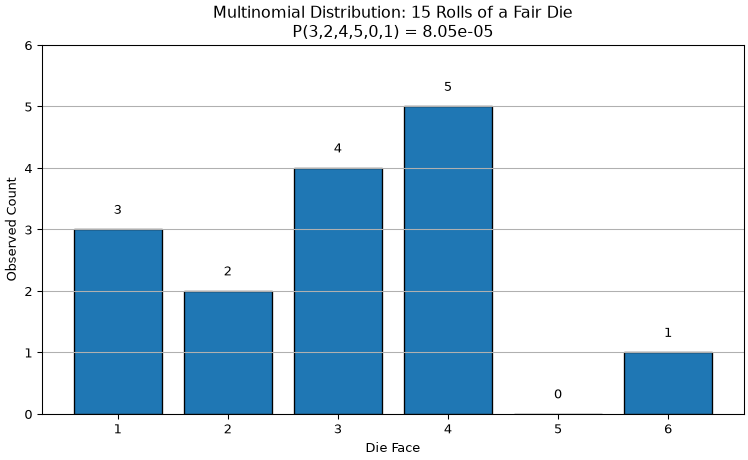

### Gaussian Distribution

The Bernoulli and Categorical distributions are PMF, i.e., distributions
over discrete random variables.

A common PDF when dealing with real values is the **Gaussian
distribution,** also known as **Normal Distribution**.

The distribution is characterized by two parameters:

-   The mean $\mu\mathfrak{\in R}$

-   The standard deviation $\sigma \in (0, + \infty)$

In practice, the distribution is often *seen in terms of* $\mu$ *and*
$\sigma^{2}$ rather than $\sigma$, where $\sigma^{2}$ is called **the
variance**.

The analytical formulation of the Normal distribution is as follows:

$$N\left( x;\mu,\sigma^{2} \right) = \sqrt{\frac{1}{2\pi\sigma^{2}}}e^{- \frac{1}{2\sigma^{2}}(x - \mu)^{2}}$$

The term under the square root is a normalization term which ensures
that the distribution integrates to 1.

The Gaussian distribution is very used when we do not have much prior
knowledge on the real distribution we wish to model. This in mainly due
to the **central limit theorem**, which states that the sum of many
independent random variables with the same distribution is approximately
normally distributed.

#### Interpretation

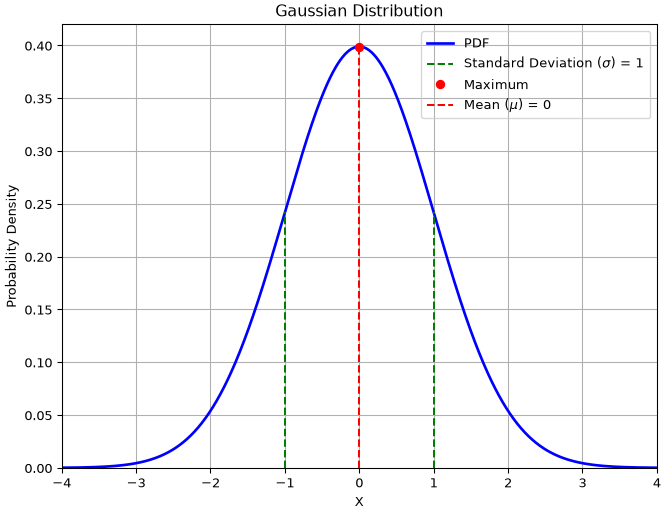

If we plot the PDF of a Normal distribution, we can find that it is easy
to interpret the meaning of its parameters:

-   The resulting curve has a maximum (highest probability) when
    $x = \mu$

-   The curve is symmetric, with the inflection points at
    $x = \mu \pm \sigma$

-   The example shows a normal distribution for $\mu = 0$ and
    $\sigma = 1$

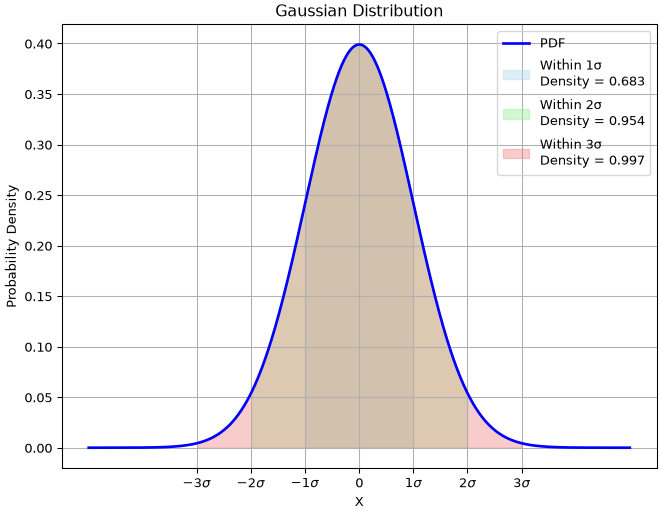

Another notable property of the Normal distribution is that:

-   About $68\%$ of the density is comprised in the interval
    $\lbrack - \sigma,\sigma\rbrack$;

-   About $95\%$ of the density is comprised in the interval
    $\lbrack - 2\sigma,2\sigma\rbrack$;

-   Almost 100% of the density is comprised in the interval
    $\lbrack - 3\sigma,3\sigma\rbrack$.

### Central Limit Theorem

The **Central Limit Theorem (CLT)** is a fundamental statistical
principle stating that the distribution of the sum (or average) of a
large number of independent and identically distributed (i.i.d.) random
variables $\{X_i\}_{i=1}^n$ tends toward a normal (Gaussian)
distribution as $n \to \infty$, regardless of the original distribution
of each $X_i$.

This result is crucial because it explains why the Gaussian distribution
is so commonly observed in data analysis and natural phenomena, even
when the underlying data are not normally distributed.

**Key points:** - The CLT applies to sums or averages of i.i.d. random
variables. - The convergence to the normal distribution becomes more
accurate as the number of variables $n$ increases. - The original
distribution of the variables can be arbitrary (e.g., uniform, binomial,
etc.).

**Illustration:**  
The plot below shows the distributions of the average outcome when
rolling different numbers of dice. Each die represents an independent
random variable. As the number of dice increases, the distribution of
the average outcome becomes increasingly similar to a Gaussian curve.

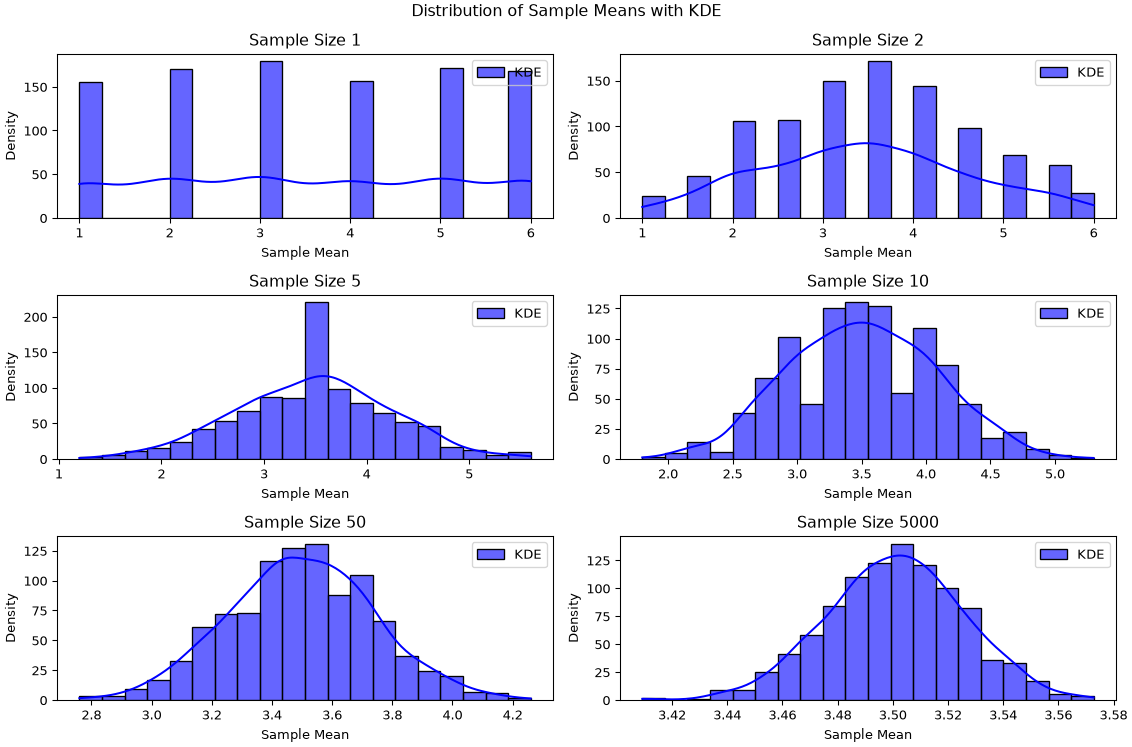

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for KDE

# Simulate rolling a fair six-sided die
num_rolls = 1000
sample_sizes = [1, 2, 5, 10, 50, 5000]

# List to store the means of each sample
sample_means = []

for sample_size in sample_sizes:
    means = [np.mean(np.random.randint(1, 7, sample_size)) for _ in range(num_rolls)]
    sample_means.append(means)

# Plot the sample means for different sample sizes with KDE
plt.figure(figsize=(12, 8))
for i, sample_size in enumerate(sample_sizes):
    plt.subplot(3, 2, i + 1)
    sns.histplot(sample_means[i], bins=20, kde=True, color='blue', label='KDE', alpha=0.6)
    plt.title(f'Sample Size {sample_size}')
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()

plt.suptitle('Distribution of Sample Means with KDE')
plt.tight_layout()
plt.show()

#### Multivariate Gaussian

The formulation of the Gaussian distribution generalizes to the
multivariate case, i.e., the case in which $X$ is d-dimensional.

In that case, the distribution is parametrized by a **d-dimensional
vector** $\mathbf{\mu}$ and a
$\mathbf{d}\mathbf{\times}\mathbf{d}\mathbf{\ }$**positive definite
symmetric matrix** $\mathbf{\Sigma}$. The formulation of the
multi-variate Gaussian is:

$$N\left( \mathbf{x;\mu,}\mathbf{\Sigma} \right) = \sqrt{\frac{1}{(2\pi)^{d}\det(\Sigma)}}e^{( - \frac{1}{2}\left( \mathbf{x} - \mathbf{\mu} \right)^{T}\Sigma^{- 1}\left( \mathbf{x} - \mathbf{\mu} \right))}$$

In the 2D case, $\mathbf{\mu}$ is a 2D point representing the center of
the Gaussian (the position of the mode), whereas the matrix $\Sigma$
influences the “shape” of the Gaussian.

Examples of bivariate Gaussian distributions are shown below.

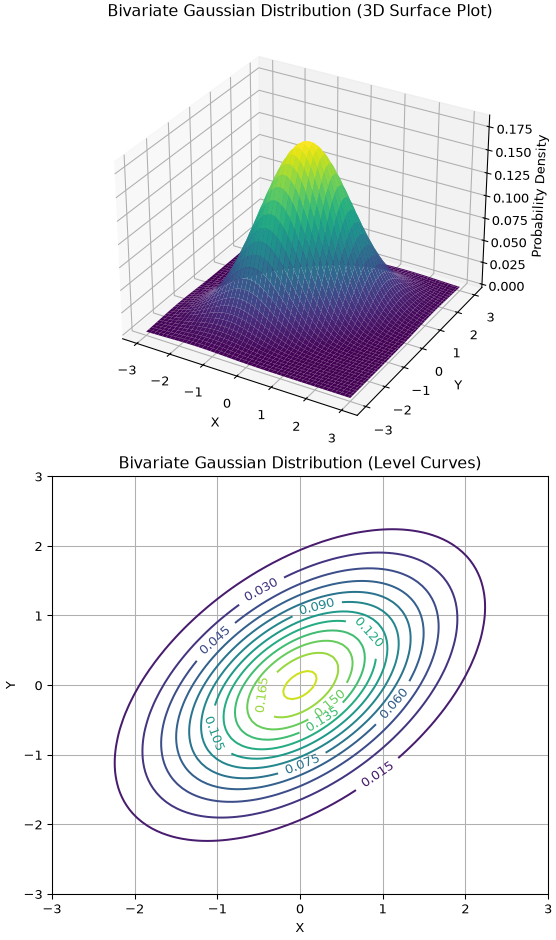

The two plots above are common representations for bivariate continuous
distributions: \* The plot on the top shows a 3D representation of the
PDF in which the X and Y axes are the values of the variables, while the
third axis reports the probability density. \* Since it’s often hard to
draw 3D graphs, we often use a contour plot to represent the 3D curves.
In the 3D plot, curves of the same color represent points which have the
same density in the 3D plot.

#### Effect of $\Sigma$

Similar to how variance affects the dispersion of a 1D Gaussian, the
covariance matrix $\Sigma$ affects the dispersion in both axes. As a
result, changing the values of the matrix will affect the shape of the
distribution. Let’s consider the general covariance matrix:

$$
\Sigma = \begin{bmatrix}
  \sigma_x^2 & \sigma_{xy} \\
  \sigma_{yx} & \sigma_y^2
\end{bmatrix}
$$

The covariance matrix $\Sigma$ determines the shape, orientation, and
spread of a bivariate Gaussian distribution: - When $\Sigma$ is diagonal
($\sigma_{xy}=\sigma_{yx}=0$), the distribution is symmetric and spreads
equally along both axes, resulting in circular contours. - If the
variances along the axes differ, the distribution becomes elongated
along the axis with higher variance. - Non-zero off-diagonal elements
introduce correlation: a positive covariance causes the distribution to
tilt so that higher values of one variable are associated with higher
values of the other, while a negative covariance produces an opposite
tilt. - Larger absolute values of covariance lead to more pronounced
stretching along a diagonal direction. When both variances and
covariances are large, the distribution is highly dispersed and strongly
correlated. These effects are clearly visible when comparing different
covariance matrices in contour plots.

Some examples are shown below:

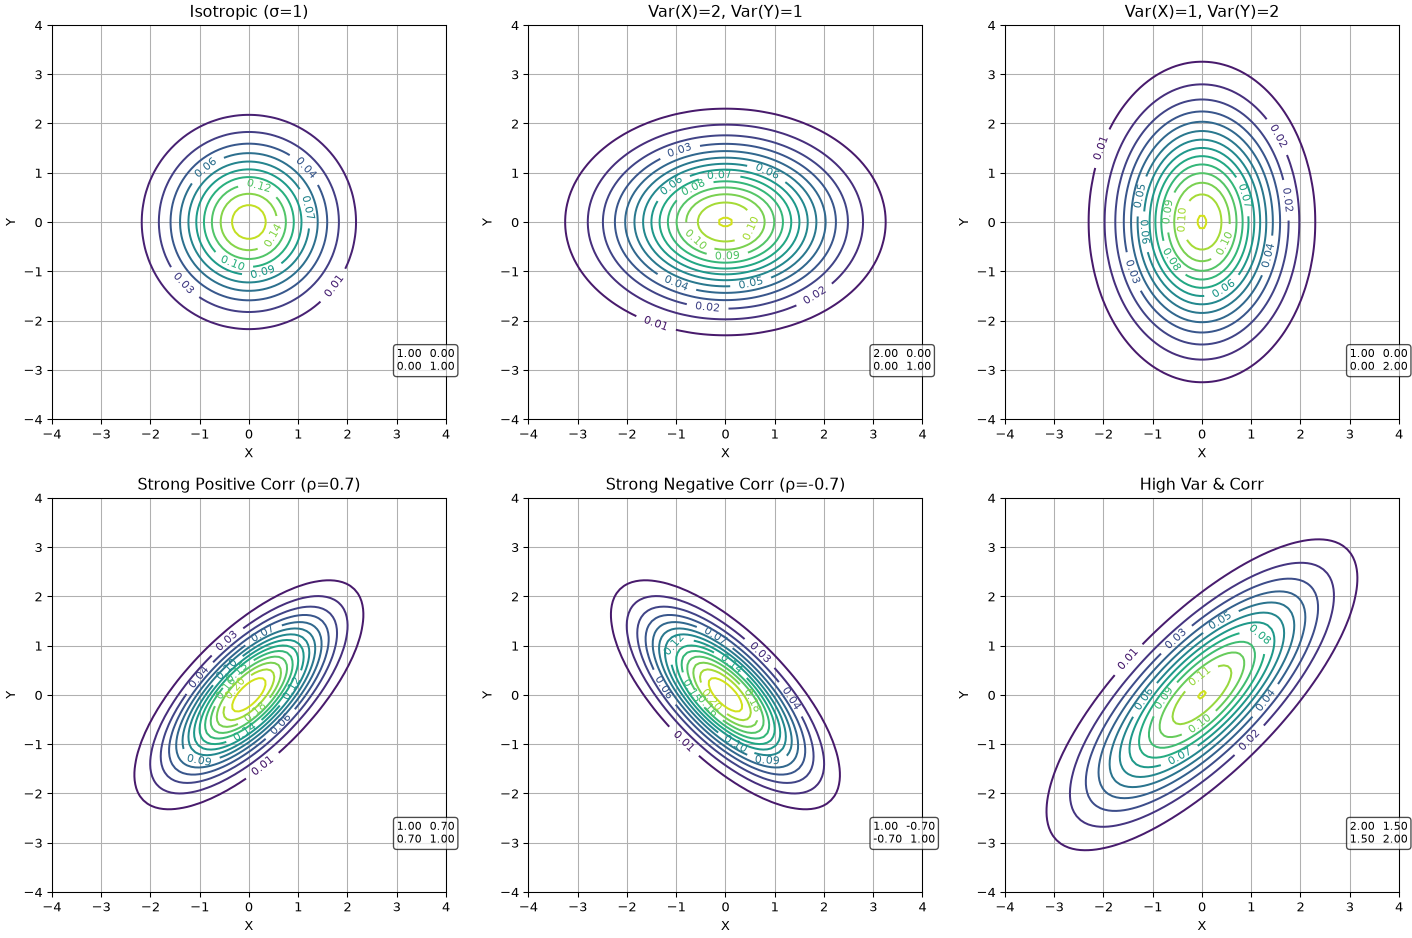

#### Estimation of the Parameters of a Gaussian Distribution

We have noted that in many cases we can assume a random variable follows
a Gaussian distribution. However, it is not yet clear how to choose the
parameters of the Gaussian distribution.

Given some data (remember, data is values assumed by random variables!),
we can obtain the parameters of the Gaussian distribution related to the
data with a **maximum likelihood** estimation.

This consists in computing the mean and variance parameters using the
following formula (in the univariate case):

-   $\mu = \frac{1}{n}\sum_{j}^{}x_{j}$

-   $\sigma^{2} = \frac{1}{n-1}\sum_{j}^{}\left( x_{j} - \mu \right)^{2}$

Where $x_{j}$ represent the different data points.

In the multi-variate case, the computation of the multi-dimensional
$\mathbf{\mu}$ vector is similar:

-   $\mathbf{\mu} = \frac{1}{n}\sum_{j}^{}\mathbf{x}_{j}$

-   $\Sigma$ is instead computed as the covariance matrix related to
    $X$: $\Sigma = Cov(\mathbf{X})$, i.e.,
    $\Sigma_{ij} = Cov\left( \mathbf{X}_{i},\mathbf{X}_{j} \right)$

The diagram below shows an example in which we fit a Gaussian to a set
of data and compare it with a 2D KDE of the data.

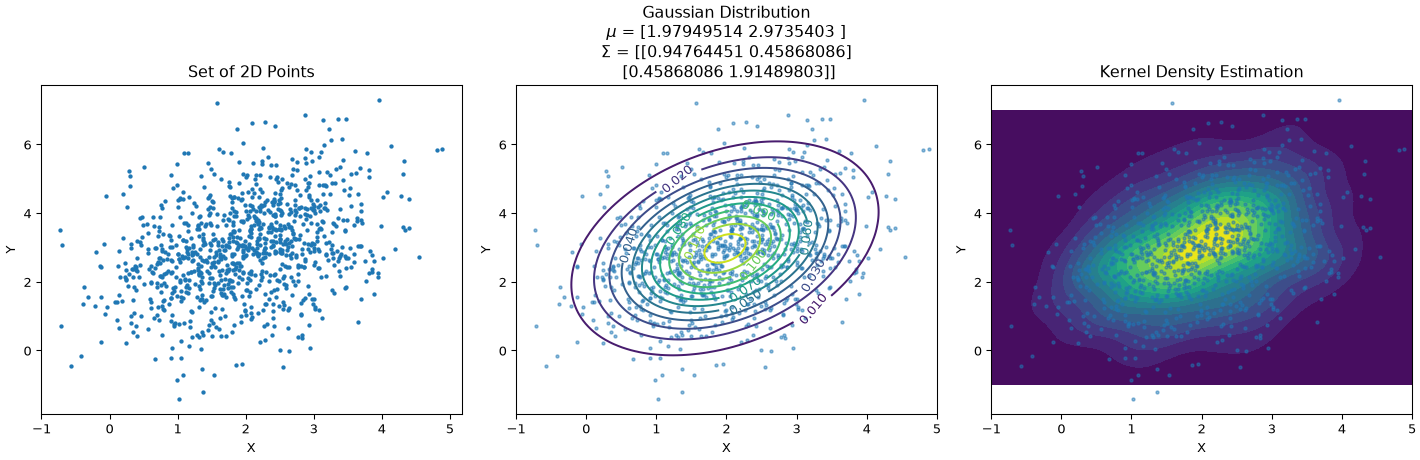

## Describing Data Distributions

To effectively summarize and interpret the properties of a probability
distribution, it is useful to rely on a set of descriptive statistics.
Measures such as **expectation** (mean), **variance**, and
**covariance** allow us to capture the central tendency, variability,
and relationships between variables, while **standardization** allows us
to compare variables on a common scale. These concepts provide essential
tools for understanding the behavior of random variables and for
analyzing data distributions in practice.

### Expectation

When it is known that a random variable follows a probability
distribution, **it is possible to characterize that variable** (and
hence the related probability distribution) **with some statistics**.

The most straightforward of them is the expectation. **The concept of
expectation is very related to the concept of mean.** When we compute
the mean of a given set of numbers, we usually sum all the numbers
together and then divide by the total.

Since a probability distribution tell us which values will be more
frequent than others, we compute this mean with a **weighted average**,
where the weights are given by the probability distribution.

Specifically, we can define the expectation of a **discrete random
variable** X as follows:

$$E_{X\sim P}\lbrack X\rbrack = \sum_{x \in \Omega}^{}{xP(x)}$$

In the case of **continuous variables**, the expectation takes the form
of an integral:

$$E_{X \sim P}\lbrack X\rbrack = \int_{x \in \Omega} xf(x)dx$$

The diagram below shows an example of expectation:

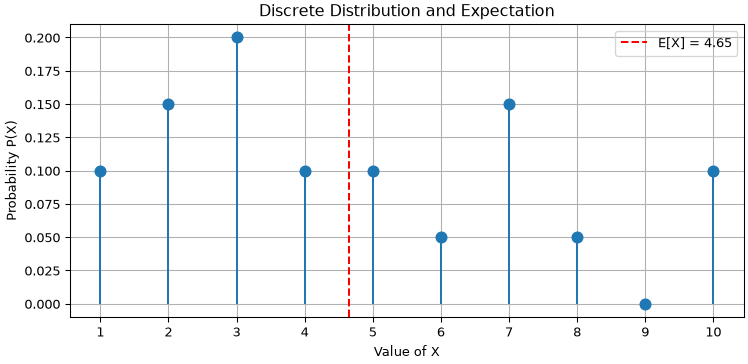

### Variance and Standard Deviation

The variance gives a measure of how much variability there is in a
variable $X$ around its mean $E\lbrack X\rbrack$.

Similarly to the concept of variance as a descriptive measure, we can
define the variance in this context as follows:

$$Var_{X \sim P}[X] = E_{X \sim P}[(X-E_{X \sim P}[X])^2]$$

As seen with data description, to make the measure of spread more
interpretable, we often use the **standard deviation**, which is simply
the square root of the variance:

$$
Std_{X \sim P}[X]=\sqrt{Var_{X \sim P}[X]}
$$

Standard deviation tells us, on average, how far values tend to deviate
from the mean, using the same units as the original variable.

The diagram below shows an example:

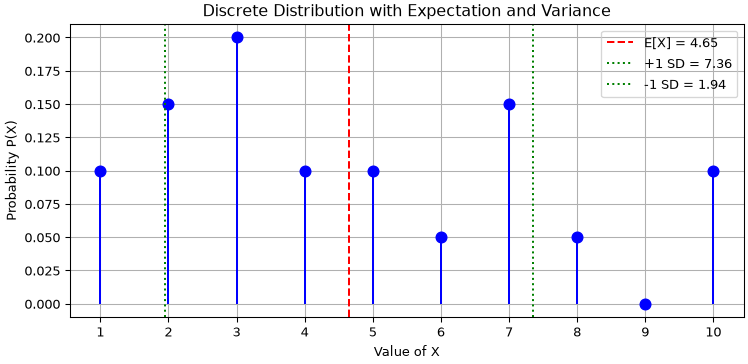

### Covariance

The covariance gives a measure of how two variables are linearly related
to each other. It allows to **measure to what extent the increase of one
of the variables corresponds to an increase of the value of the other
one**.

Given two random variables $X \sim P_X$ and $Y \sim P_Y$, the covariance
is defined as follows:

$$Cov_{X \sim P_X, Y \sim P_Y}(X,Y) = E_{X \sim P_X, Y \sim P_Y}\lbrack\left( X - E_{X \sim P_X}\lbrack X\rbrack \right)\left( Y - E_{Y \sim P_Y}\lbrack Y\rbrack \right)\rbrack$$

We can distinguish the following terms:

-   $E\lbrack X\rbrack$ and $E\lbrack Y\rbrack$ are the expectations of
    $X$ and $Y.$

-   $(X - E\lbrack X\rbrack)$ and $(Y - E\lbrack Y\rbrack)$ are the
    differences between the samples and the expected values.

-   $\left( X - E\lbrack X\rbrack \right)\left( Y - E\lbrack Y\rbrack \right)$
    computes the product between the differences.

We have: \* If the signs of the terms agree, the product is positive. \*
If the signs of the terms disagree, the product is negative.

In practice, if when $X$ is larger than the mean, then $Y$ is larger
than the mean and vice versa, when $X$ is lower than the mean then $Y$
is lower than the mean, then the two variables are *correlated,* and the
covariance is high.

If $X$ is a multi-dimensional variable
$X = \lbrack X_{1},X_{2},\ldots,X_{n}\rbrack$, we can compute all the
possible covariances between variable pairs:
$Cov\lbrack X_{i},X_{j}\rbrack$. This allows to create a matrix, which
is generally referred to as **the covariance matrix**. The general term
of the covariance matrix $Cov(X)$ is given by:

$$Cov(X)_{i,j} = \Sigma_{ij} = Cov(X_{i},X_{j})$$

### Entropy (Optional)

Another fundamental way to characterize a probability distribution is
through **entropy**, which measures the average uncertainty or
unpredictability associated with the possible values of a random
variable.

#### Self-Information

To understand entropy, we first introduce the concept of
**self-information**. The self-information of an event $x$ with
probability $P(x)$ is defined as:

$$
I(x) = -\log_2 P(x)
$$

(we will use $\log$ in the future in this context to denote $\log_2$ for
brevity)

This definition is motivated by several properties of the logarithm:

-   The logarithm makes self-information **additive** for independent
    events: the information gained from observing two independent events
    is the sum of their individual self-informations.

$$
I(X = x,Y = y) = - \log\left\lbrack P(X = x,Y = y) \right\rbrack = $$

$$
= \log\left\lbrack P(X = x)P(Y = y) \right\rbrack = - logP(X = x) - \log P(Y = y) = I(x) + I(y)
$$ - The negative logarithm reflects the intuition that **rare events
are more informative**: as $P(x)$ decreases, $I(x)$ increases (see plot
below) - The base 2 logarithm measures information in **bits**, which is
standard in information theory

For example, if an event is certain ($P(x)=1$), $I(x)=0$ (no new
information). If an event is very unlikely ($P(x)\to 0$),
$I(x)\to \infty$ (maximum surprise).

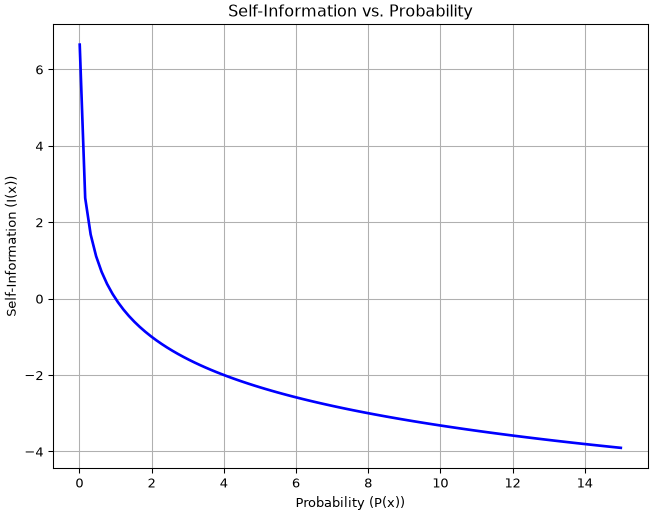

#### Entropy of a Distribution

The **entropy** of a random variable $X$ is the average self-information
over all possible values of $X$, weighted by their probabilities (i.e.,
the expected self-information):

-   For discrete variables: $$
    H(X) = -\sum_{x \in \Omega} P(x) \log_2 P(x)
    $$
-   For continuous variables (differential entropy): $$
    h(X) = -\int_{x \in \Omega} f(x) \log_2 f(x) dx
    $$

Entropy is highest when the distribution is uniform (maximum
uncertainty) and lowest when the distribution is concentrated on a few
values (minimum uncertainty).

> **Note:** Entropy is measured in bits if the logarithm base 2 is used
> and nats if we use a natural logarithm (base $e$).

#### Example

-   A fair coin ($P(head)=0.5$, $P(tail)=0.5$): $H(X) = 1$ bit.
-   A highly biased coin ($P(head)=0.99$, $P(tail)=0.01$):
    $H(X) \approx 0.08$ bits.

Entropy thus provides a synthetic measure of the uncertainty of a
distribution, useful for comparing different random variables and for
applications in information theory and machine learning.

#### Entropy of a Bernoulli variable

Let’s consider a variable $X$ following a Bernoulli distribution with
probability $p$, i.e.:

$$X_p = \begin{cases}
1 & \text{with probability } p\\
0 & \text{with probability } 1-p
\end{cases}
$$

Then the entropy of this variable will be:

$$H(X_p) = -p\log p -(-1-p)\log(1-p)$$

If we plot $H(X_p)$ with respect to $p$, we obtain the following graph:

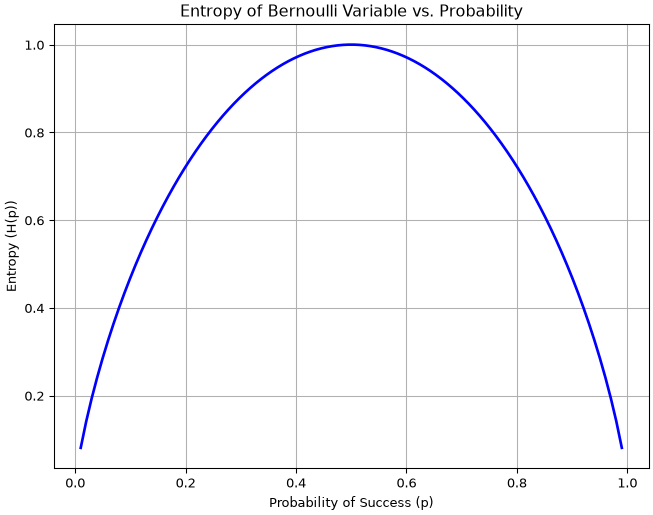

## Standardization

Standardization transforms a random variable $X$ into a variable $Z$ so
that it has: \* Expectation equal to zero: $E(Z) = 0$. \* Variance equal
to one: $Var(Z) = 1$.

The standardized variable will be:

$$Z = \frac{X - \mu_X}{\sigma_X} = \frac{X-E[X]}{\sqrt{Var[X]}}$$

The plot below shows a data distribution before and after
standardization.

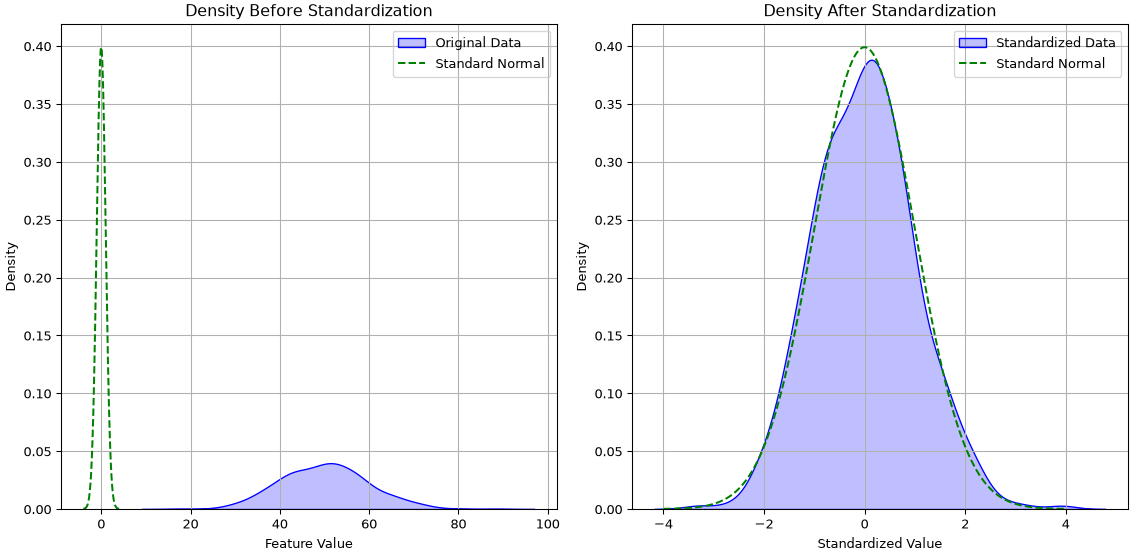

## Fitting Distributions to Data

Often, we want to fit a theoretical probability distribution to observed
data. This means estimating the parameters of the distribution so that
it best describes the data. In Python, this can be done easily using
`scipy.stats`.

Below is an example of fitting a normal (Gaussian) distribution to a
dataset:

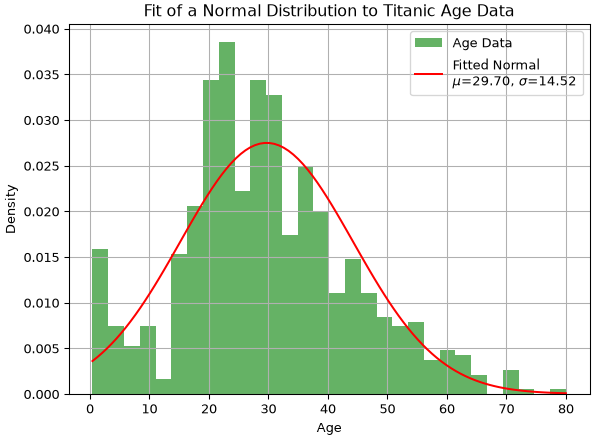

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load the Titanic dataset
titanic = pd.read_csv(DATA + "titanic.csv", index_col='PassengerId')

# Extract the Age column and drop missing values
ages = titanic['Age'].dropna()

# Fit a normal distribution to the Age data
mu_hat, sigma_hat = norm.fit(ages)

# Plot the histogram of Age
plt.hist(ages, bins=30, density=True, alpha=0.6, color='g', label='Age Data')

# Plot the fitted normal distribution
x = np.linspace(ages.min(), ages.max(), 100)
pdf_fitted = norm.pdf(x, loc=mu_hat, scale=sigma_hat)
plt.plot(x, pdf_fitted, 'r-', label=f'Fitted Normal\n$\mu$={mu_hat:.2f}, $\sigma$={sigma_hat:.2f}')

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Fit of a Normal Distribution to Titanic Age Data')
plt.legend()
plt.grid(True)
plt.show()

We can do the same with other distribution. For instance, with the
binomial distribution:

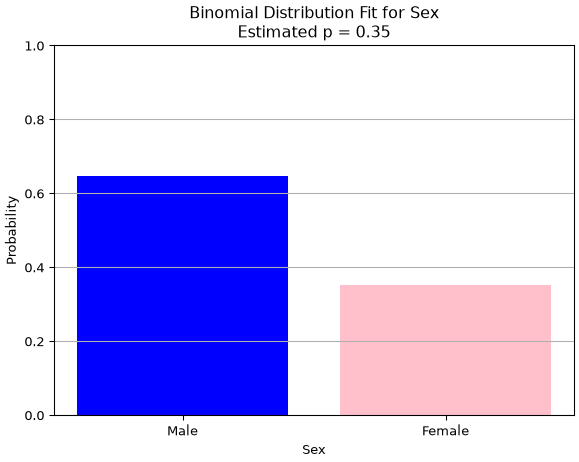

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

# Load the Titanic dataset
titanic = pd.read_csv(DATA + "titanic.csv", index_col='PassengerId')

# Encode 'Sex': female=1, male=0
sex_numeric = (titanic['Sex'] == 'female').astype(int)

# Estimate p (probability of being female)
p_hat = sex_numeric.mean()
n = len(sex_numeric)

# Binomial PMF for n trials (here, n=1 for each passenger)
x = [0, 1]
pmf = binom.pmf(x, n=1, p=p_hat)

# Plot the PMF
plt.bar(['Male', 'Female'], pmf, color=['blue', 'pink'])
plt.title(f'Binomial Distribution Fit for Sex\nEstimated p = {p_hat:.2f}')
plt.ylabel('Probability')
plt.xlabel('Sex')
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()

## Exercises

1.  **Recognise the shape.** Plot the distribution of `Fare` and of
    `Age` in the Titanic data. Describe each in words: symmetric or
    skewed, unimodal or not, heavy-tailed or not. Which summary
    statistic would you report for each, and why?
2.  **Fit and check.** Fit a normal distribution to `Age` and overlay it
    on the histogram. Then produce a Q-Q plot. Where does the fit fail,
    and does it matter for a statement about the mean age?
3.  **The log-normal.** Plot `Fare` on a logarithmic axis. Does the
    transformed variable look normal? What does it mean, in the language
    of the problem, if fares are log-normally distributed?
4.  **Simulate the central limit theorem.** Draw 1000 samples of size
    $n$ from a strongly skewed distribution (an exponential, say) for
    $n \in \{2, 5, 30, 100\}$, and plot the distribution of the sample
    means. At which $n$ does it start to look normal?
5.  **Discrete distributions.** `SibSp` counts siblings and spouses
    aboard. Fit a Poisson distribution to it and compare the expected
    and observed counts. Where does the Poisson model break down, and
    what feature of the data explains it?

## References

-   Parts of chapter 1 of \[1\];

-   Most of chapter 3 of \[2\];

-   Parts of chapter 8 of \[3\].

\[1\] Bishop, Christopher M. *Pattern recognition and machine learning*.
springer, 2006.
<https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf>

\[2\] Goodfellow, Ian, Yoshua Bengio, and Aaron Courville. *Deep
learning*. MIT press, 2016. <https://www.deeplearningbook.org/>

\[3\] Heumann, Christian, and Michael Schomaker Shalabh. Introduction to
statistics and data analysis. Springer International Publishing
Switzerland, 2016.